# FGSEA analysis

In [ ]:
Here we will describe how to perform fgsea analysis on MSIGDB data

MSIGDB (for molecular signature database) gene sets (in `gmt` format) have been downloaded from [Msigdb website](https://www.gsea-msigdb.org/gsea/msigdb/human/collections.jsp), and saved in `projectnb/tcwlab/MSigDB`
We have downloaded and analyzed only the CP: Canonical pathways, containing notably the curated KEGG and REACTOME pathways, and C5: ontology gene sets, containing all Gene ontology (GO) terms. 


In [ ]:
## Set up the analysis

In [10]:
 out<-'../outputs/01-SEAAD_data/fgsea'
dir.create(out)

source('../../../utils/r_utils.R')
library(fgsea)



Warning message in dir.create(out):
“'../outputs/01-SEAAD_data/fgsea' already exists”
28 threads available for data.table



## Prepare the differential expression results
we need to check that the genes are in gene symbol format (gene names), and that there is no duplicated gene names.
We also need here to define/calculate the gene statistics/score that we will used. 
Here the score used is the statistic of the deseq2 results already save in the 'stat' column, so we do not need to do supplementatl validation. For others case like differential expresults from `FindMarkers()` Seurat function, such `stat` column is not present, we have to use another score as differential results. Most of the time we are using `sign(avg_log2FC)*-log10(p_value)` as score.

**NOTE:** It can also be used for any analysis generating a score/statistic by gene
Here we used the astrocyte differential expression generated previously

In [8]:
#set the stat column
stat_column='stat'

#IF from FindMarkers() results / no stat column present, need to create a new column
#res_de[,diff_score:=sign(avg_log2FC)-log10(p_value)]
#stat_column='diff_score'


In [4]:

#load data
res_de<-rbindlist(list(fread('../outputs/01-SEAAD_data/pseudobulk_deseq2/res_pseudobulkDESeq2_No.dementia_APOE4_vs_3_astro_DLPFC_Cov_sex_braak_atherosclerosis_PMI_ncells_nUmis_LibInput_PCRcycles_avg.mt.csv.gz'),
                   fread('../outputs/01-SEAAD_data/pseudobulk_deseq2/res_pseudobulkDESeq2_No.dementia_APOE4_vs_3_astro_MTG_Cov_sex_braak_atherosclerosis_PMI_ncells_nUmis_LibInput_PCRcycles_avg.mt.csv.gz')))
#Prep data
#duplicate gene names?
res_de[,is.dup:=duplicated(gene),by='brain_region']
res_de[,n.dup:=sum(is.dup),by=.(brain_region,gene)]
table(res_de$n.dup)

# if duplicates, remove the duplicate with the smallest score/statistic
#res_de[order(brain_region,-abs(stat)),to_rm:=duplicated(gene),by='brain_region']
#res_de<-res_de[!(to_rm)]



    0 
42752 

Here we do not have duplicates so we can continue. 
To run fgsea, you can use either the native way using the gmt file, or the pre build function that used the already preprocessed gmt files

## Native way

specify the path to MSIGDB gmt files and which pathway category to test

In [11]:


pathways_dir <- "/projectnb/tcwlab/MSigDB/"
pathways_to_test<-c("GO_all", 'CP_all') # choose pathway gene sets reference you want to test or let like that to test for all

pathways_info<-fread(file.path(pathways_dir,'all_CPandGOs_genesets_metadata.csv.gz'))
gmt_mtd<-fread(file.path(pathways_dir,'gmt_metadata.csv')) #contain the gmt files names and corresponding gene set category names


In [12]:


res_gsea_all<-Reduce(rbind,lapply(unique(res_de$brain_region), function(br){
  
  message(paste('testing enrichement in',br))
  
  res_def<-res_de[brain_region==br]
  #calculate/extract the gene stats
  gene_stats<-setNames(res_def[[stat_column]],res_def$gene)
  
  #run fgsea for every pathway source
  res_gsea<-Reduce(rbind,lapply(pathways_to_test, function(p){
    
    message(paste('testing enrichement for',gmt_mtd[name==p]$desc))
    
    pathways<- gmtPathways(file.path(pathways_dir,gmt_mtd[name==p]$gmt))
    
    res<-fgsea(pathways,
               stats=gene_stats,minSize=10,maxSize=2000,scoreType='std')
    
    return(res[,source:=p])
    
  }))
  return(res_gsea[,brain_region:=br])
  
  
  
}))



testing enrichement in DLPFC

testing enrichement for GO All

testing enrichement for CP All

testing enrichement in MTG

testing enrichement for GO All

testing enrichement for CP All



We add information about the pathways and save

In [ ]:
#res_gsea_all<-merge(res_gsea_all,pathways_info,by=c('pathway'))[order(brain_region,source,subcat,pval)]
table(res_gsea_all[padj<0.05]$brain_region)


In [ ]:
fwrite(res_gsea_all,fp(out,"res_fgsea_APOE4vs3_NL_astrocytes.csv.gz"))



## pre build function
This analysis can be run simply and more efficiently using the prebuild functions available in the `alexandre-utils/deseq2_utils.R` functions

In [15]:
source('../../../utils/deseq2_utils.R')
res_gsea_all<-RunFgseaMsigdb(res_de = res_de,group.by = 'brain_region',score = stat_column)


testing msigdb pathway enrichment in DLPFC

testing msigdb pathway enrichment in MTG



In [ ]:
head(res_gsea_all)


## See the results using emmaplot
Now we can check the number of pathways enriched (padj<0.05) and see the emmaplot

In [18]:
table(res_gsea_all[padj<0.05]$query)


DLPFC   MTG 
  386   833 

And see the emmaplot, for example the top100 of MTG brain region

Loading required package: igraph


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union


Loading required package: ggraph

Warning message in stri_extract_all_regex(string, pattern, simplify = simplify, :
“argument is not an atomic vector; coercing”
Warning message:
“`aes_()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`”
Warning message:
“Using the `size` aesthetic in this geom was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` in the `default_aes` field and elsewhere instead.”
Warning message:
“ggrepel: 7 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


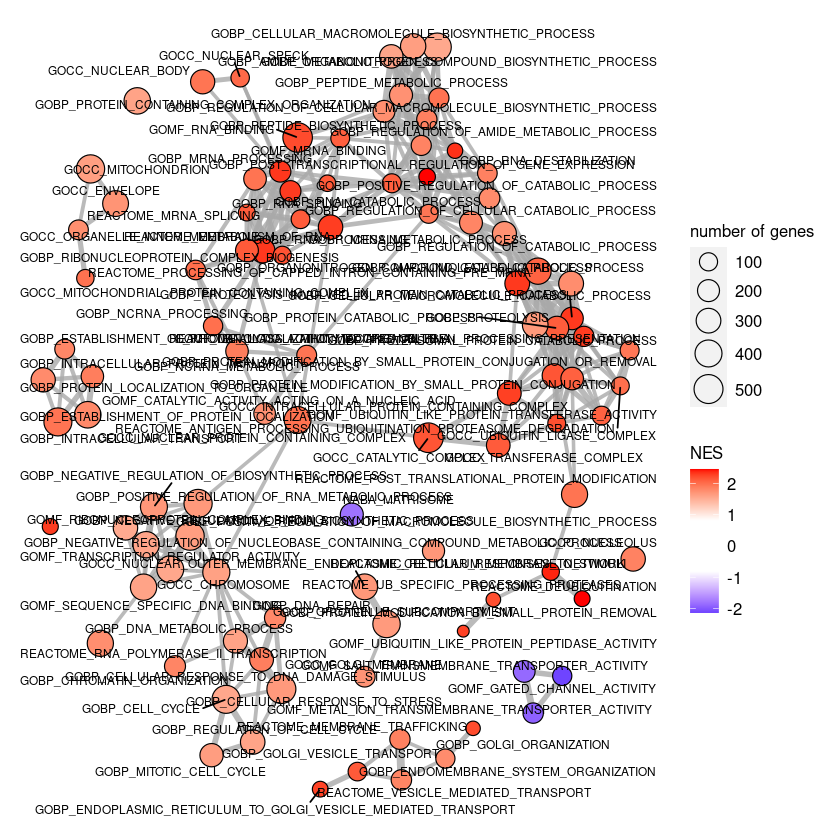

In [21]:
source('../../../utils/emmaplot.R')

res_gsea_sig<-res_gsea_all[padj<0.05]
res_gsea_top100_MTG<-head(res_gsea_sig[query=='MTG'][order(padj)],100)

emmaplot(res_gsea_top100_MTG)


The output will look better if you saved as pdf with bigger size of course